In [2]:
import pandas as pd
df = pd.read_csv("D:\Customer-Intelligence-Growth-Analytics/data/processed/telco_customer_clean.csv")


In [3]:
total_revenue = df["Total Charges"].sum()

print(f"Total Revenue : ${total_revenue:,.2f}")

Total Revenue : $16,056,168.70


In [4]:
monthly_revenue = df["Monthly Charges"].sum()

print(f"Monthly Revenue : ${monthly_revenue:,.2f}")

Monthly Revenue : $456,116.60


In [5]:
contract_revenue = (
    df.groupby("Contract")
      .agg(
          Customers=("CustomerID","count"),
          Total_Revenue=("Total Charges","sum"),
          Avg_Revenue=("Total Charges","mean")
      )
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)

contract_revenue

,Contract,Customers,Total_Revenue,Avg_Revenue
0,Two year,1695,6283253.7,3706.934336
1,Month-to-month,3875,5305861.5,1369.254581
2,One year,1473,4467053.5,3032.622878


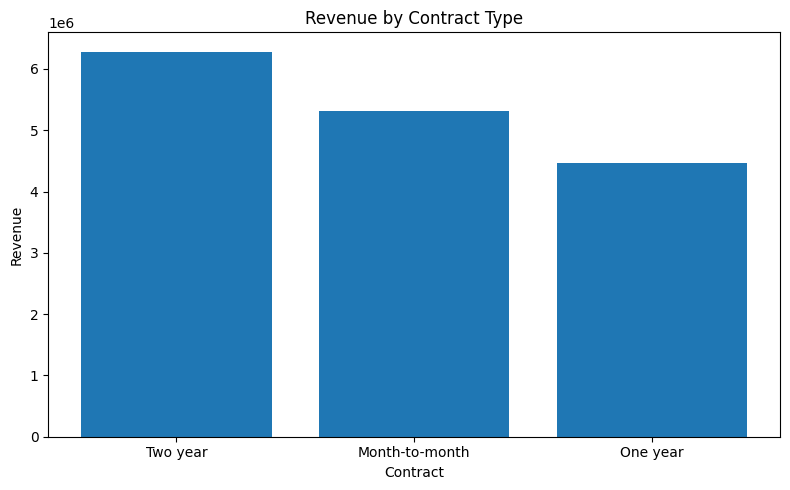

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    contract_revenue["Contract"],
    contract_revenue["Total_Revenue"]
)

plt.title("Revenue by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

***Here clearly we can see 2year contract customer generate more revenue***

In [8]:
internet_revenue = (
    df.groupby("Internet Service")
      .agg(
          Customers=("CustomerID","count"),
          Revenue=("Total Charges","sum"),
          Average_Revenue=("Total Charges","mean")
      )
      .sort_values("Revenue", ascending=False)
      .reset_index()
)

internet_revenue

,Internet Service,Customers,Revenue,Average_Revenue
0,Fiber optic,3096,9923622.95,3205.304570
1,DSL,2421,5121410.85,2115.411338
2,No,1526,1011134.90,662.604784


In [9]:
payment_revenue = (
    df.groupby("Payment Method")
      .agg(
          Customers=("CustomerID","count"),
          Revenue=("Total Charges","sum")
      )
      .sort_values("Revenue", ascending=False)
      .reset_index()
)

payment_revenue

,Payment Method,Customers,Revenue
0,Electronic check,2365,4944903.25
1,Bank transfer (automatic),1544,4748279.90
2,Credit card (automatic),1522,4671593.35
3,Mailed check,1612,1691392.20


In [10]:
gender_revenue = (
    df.groupby("Gender")
      .agg(
          Customers=("CustomerID","count"),
          Revenue=("Total Charges","sum"),
          Average_Revenue=("Total Charges","mean")
      )
      .reset_index()
)

gender_revenue
#we can confirm that gender is not the churn problem

,Gender,Customers,Revenue,Average_Revenue
0,Female,3488,7952354.2,2279.918062
1,Male,3555,8103814.5,2279.554008


In [11]:
payment_count = (
    df.groupby("Payment Method")
      .agg(
          Customers=("CustomerID", "count"),
          Revenue=("Total Charges", "sum"),
          Avg_Revenue=("Total Charges", "mean"),
          Avg_Monthly_Charges=("Monthly Charges", "mean"),
          Avg_Tenure=("Tenure Months", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

payment_count

,Customers,Revenue,Avg_Revenue,Avg_Monthly_Charges,Avg_Tenure
Payment Method,,,,,
Electronic check,2365,4944903.25,2090.868182,76.255814,25.174630
Bank transfer (automatic),1544,4748279.90,3075.310816,67.192649,43.656736
Credit card (automatic),1522,4671593.35,3069.378022,66.512385,43.269382
Mailed check,1612,1691392.20,1049.250744,43.917060,21.830025


In [12]:
payment_churn = (
    df.groupby("Payment Method")
      .agg(
          Customers=("CustomerID", "count"),
          Churned=("Churn Value", "sum")
      )
)

payment_churn["Churn Rate (%)"] = (
    payment_churn["Churned"] /
    payment_churn["Customers"] * 100
).round(2)

payment_churn

,Customers,Churned,Churn Rate (%)
Payment Method,,,
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11


Customers using Electronic Check have the highest churn rate at approximately 45%, 
which is substantially higher than all other payment methods.

In [13]:
pd.crosstab(
    df["Payment Method"],
    df["Contract"],
    margins=True
)

Contract,Month-to-month,One year,Two year,All
Payment Method,,,,
Bank transfer (automatic),589,391,564,1544
Credit card (automatic),543,398,581,1522
Electronic check,1850,347,168,2365
Mailed check,893,337,382,1612
All,3875,1473,1695,7043


In [14]:
pd.crosstab(
    df["Payment Method"],
    df["Internet Service"],
    margins=True
)

Internet Service,DSL,Fiber optic,No,All
Payment Method,,,,
Bank transfer (automatic),566,646,332,1544
Credit card (automatic),594,597,331,1522
Electronic check,648,1595,122,2365
Mailed check,613,258,741,1612
All,2421,3096,1526,7043


In [15]:
df.groupby("Payment Method")["Monthly Charges"]\
  .mean()\
  .sort_values(ascending=False)

Payment Method
Electronic check             76.255814
Bank transfer (automatic)    67.192649
Credit card (automatic)      66.512385
Mailed check                 43.917060
Name: Monthly Charges, dtype: float64

In [17]:
pd.crosstab(
    df["Payment Method"],
    df["Churn Label"]
)

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


In [18]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"]
)

Churn Label,No,Yes
Internet Service,,
DSL,1962,459
Fiber optic,1799,1297
No,1413,113


In [19]:
monthly_churn_reason = (
    df[
        (df["Contract"] == "Month-to-month") &
        (df["Churn Label"] == "Yes")
    ]["Churn Reason"]
    .value_counts()
    .reset_index()
)

monthly_churn_reason.columns = ["Churn Reason", "Customers"]

monthly_churn_reason

,Churn Reason,Customers
0,Attitude of support person,174
1,Competitor offered higher download speeds,161
2,Don't know,141
3,Competitor offered more data,140
4,Competitor made better offer,126
5,Competitor had better devices,116
6,Attitude of service provider,115
7,Network reliability,92
8,Price too high,89
9,Product dissatisfaction,85


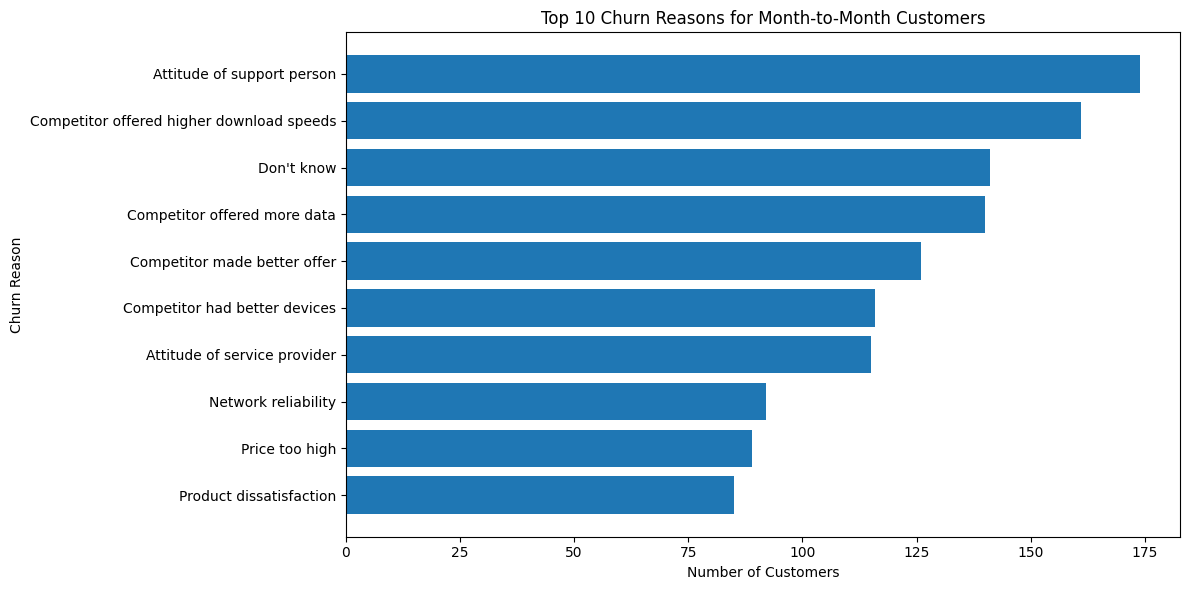

In [21]:
import matplotlib.pyplot as plt

top10 = monthly_churn_reason.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["Churn Reason"],
    top10["Customers"]
)

plt.title("Top 10 Churn Reasons for Month-to-Month Customers")

plt.xlabel("Number of Customers")
plt.ylabel("Churn Reason")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

yearly customer churn analysia

In [22]:
one_year = df[df["Contract"] == "One year"]

print("Total One-Year Customers:", one_year.shape[0])

Total One-Year Customers: 1473


In [23]:
one_year_churn = (
    one_year["Churn Label"]
    .value_counts()
    .reset_index()
)

one_year_churn.columns = ["Churn", "Customers"]

one_year_churn

,Churn,Customers
0,No,1307
1,Yes,166


In [24]:
one_year.agg(
    Total_Customers=("CustomerID","count"),
    Total_Revenue=("Total Charges","sum"),
    Avg_Monthly_Charge=("Monthly Charges","mean"),
    Avg_Total_Charge=("Total Charges","mean"),
    Avg_CLTV=("CLTV","mean"),
    Avg_Tenure=("Tenure Months","mean")
)

,CustomerID,Total Charges,Monthly Charges,CLTV,Tenure Months
Total_Customers,1473.0,NaN,NaN,NaN,NaN
Total_Revenue,NaN,4.467054e+06,NaN,NaN,NaN
Avg_Monthly_Charge,NaN,NaN,65.048608,NaN,NaN
Avg_Total_Charge,NaN,3.032623e+03,NaN,NaN,NaN
Avg_CLTV,NaN,NaN,NaN,4529.955872,NaN
Avg_Tenure,NaN,NaN,NaN,NaN,42.044807


In [25]:
one_year_reason = (
    one_year[
        one_year["Churn Label"]=="Yes"
    ]["Churn Reason"]
    .value_counts()
    .reset_index()
)

one_year_reason.columns = ["Reason","Customers"]

one_year_reason

,Reason,Customers
0,Competitor offered higher download speeds,23
1,Attitude of service provider,17
2,Attitude of support person,16
3,Competitor offered more data,16
4,Don't know,12
5,Network reliability,10
6,Moved,10
7,Product dissatisfaction,10
8,Competitor made better offer,10
9,Competitor had better devices,10


In [26]:
comparison = (
    df.groupby("Contract")
      .agg(
          Customers=("CustomerID","count"),
          Churn_Rate=("Churn Value","mean"),
          Avg_Monthly_Charge=("Monthly Charges","mean"),
          Avg_CLTV=("CLTV","mean"),
          Avg_Tenure=("Tenure Months","mean"),
          Total_Revenue=("Total Charges","sum")
      )
      .reset_index()
)

comparison["Churn_Rate"] = (
    comparison["Churn_Rate"]*100
).round(2)

comparison

,Contract,Customers,Churn_Rate,Avg_Monthly_Charge,Avg_CLTV,Avg_Tenure,Total_Revenue
0,Month-to-month,3875,42.71,66.398490,4136.708387,18.036645,5305861.5
1,One year,1473,11.27,65.048608,4529.955872,42.044807,4467053.5
2,Two year,1695,2.83,60.770413,4890.214159,56.735103,6283253.7
